### SAME GRID DIFFUSION + POISSON


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [1]:
def vorticity(x,y,t,nu):
    decay = np.exp(-2*nu*t)
    return 2*np.sin(x)*np.sin(y)*decay

In [3]:
def m4prime_1d(s):
    """
    Monaghan's M4' remeshing kernel (paper Eq. 53-54):

        W(s) = 1 - 5/2 |s|^2 + 3/2 |s|^3            for |s| <= 1
        W(s) = 1/2 (1-|s|)(2-|s|)^2                  for 1 <= |s| <= 2
        W(s) = 0                                      otherwise

    Piecewise cubic, C^1, support [-2, 2], order p=2 (conserves circulation,
    linear impulse and angular impulse).
    """
    s = np.abs(np.asarray(s, dtype=float))
    w = np.zeros_like(s)

    m1 = s <= 1.0
    m2 = (s > 1.0) & (s <= 2.0)

    w[m1] = 1.0 - 2.5 * s[m1] ** 2 + 1.5 * s[m1] ** 3
    w[m2] = 0.5 * (1.0 - s[m2]) * (2.0 - s[m2]) ** 2
    return w

In [4]:

def p2m(particles, mesh, h):

    Nx, Ny = mesh.shape

    mesh.fill(0.0)

    for p in particles:

        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        i = int(xp // h) % Nx
        j = int(yp // h) % Ny

        dx = (xp - i*h)/h
        dy = (yp - j*h)/h

        ip = (i + 1) % Nx
        jp = (j + 1) % Ny

        mesh[i,  j ] += (1-dx)*(1-dy) * p["a"] / h**2
        mesh[ip, j ] += dx*(1-dy)     * p["a"] / h**2
        mesh[i,  jp] += (1-dx)*dy     * p["a"] / h**2
        mesh[ip, jp] += dx*dy         * p["a"] / h**2

    return mesh
"""

def p2m(particles, mesh, h):
    Nx, Ny = mesh.shape
    mesh.fill(0.0)

    for p in particles:
        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        # Base index of the cell the particle sits in
        i0 = int(np.floor(xp / h))
        j0 = int(np.floor(yp / h))

        # M4' has support [-2h, 2h], so stencil spans i0-1 to i0+2 (4 nodes)
        for di in range(-1, 3):
            for dj in range(-1, 3):
                ig = (i0 + di) % Nx
                jg = (j0 + dj) % Ny

                # Normalised distances in x and y separately
                sx = (xp - (i0 + di) * h) / h
                sy = (yp - (j0 + dj) * h) / h

                # 2D kernel is tensor product of two 1D kernels
                w = m4prime_1d(sx) * m4prime_1d(sy)

                mesh[ig, jg] += w * p["a"] / h**2

    return mesh"""

'\n\ndef p2m(particles, mesh, h):\n    Nx, Ny = mesh.shape\n    mesh.fill(0.0)\n\n    for p in particles:\n        xp = np.real(p["pos"])\n        yp = np.imag(p["pos"])\n\n        # Base index of the cell the particle sits in\n        i0 = int(np.floor(xp / h))\n        j0 = int(np.floor(yp / h))\n\n        # M4\' has support [-2h, 2h], so stencil spans i0-1 to i0+2 (4 nodes)\n        for di in range(-1, 3):\n            for dj in range(-1, 3):\n                ig = (i0 + di) % Nx\n                jg = (j0 + dj) % Ny\n\n                # Normalised distances in x and y separately\n                sx = (xp - (i0 + di) * h) / h\n                sy = (yp - (j0 + dj) * h) / h\n\n                # 2D kernel is tensor product of two 1D kernels\n                w = m4prime_1d(sx) * m4prime_1d(sy)\n\n                mesh[ig, jg] += w * p["a"] / h**2\n\n    return mesh'

In [5]:
def grid_solver (omega, h, nu):

    Nx = omega.shape[0]
    Ny = omega.shape[1]

    dx, dy = h, h

    kx=2*np.pi*np.fft.fftfreq(Nx,d=dx)
    ky=2*np.pi*np.fft.fftfreq(Ny,d=dy)

    KX,KY=np.meshgrid(kx,ky,indexing="ij")
    K2=KX**2+KY**2

    K2[0,0]=1.0


    #diffusion

    omega_hat=np.fft.fft2(omega)

    diffusion = np.exp(-nu * K2 * dt)

    omega_hat *= diffusion

    omega = np.real(np.fft.ifft2(omega_hat))


    #poisson solver

    omega_hat=np.fft.fft2(omega)

    psi_hat=omega_hat/K2
    psi_hat[0,0]=0.0

    psi=np.real(np.fft.ifft2(psi_hat))

    u_hat=1j*KY*psi_hat
    v_hat=-1j*KX*psi_hat

    u=np.real(np.fft.ifft2(u_hat))
    v=np.real(np.fft.ifft2(v_hat))

    U = u + 1j * v   

    return U, omega

In [ ]:
def m2p(particles, w, U, h):

    Nx, Ny = w.shape

    for p in particles:

        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        # Base cell indices (periodic)
        i = int(xp // h) % Nx
        j = int(yp // h) % Ny

        # Fractional distance inside the cell
        dx = (xp - i*h) / h
        dy = (yp - j*h) / h

        # Neighbouring indices (periodic)
        ip = (i + 1) % Nx
        jp = (j + 1) % Ny

        # Interpolate velocity
        up = (
            U[i,  j ] * (1-dx) * (1-dy) +
            U[ip, j ] * dx     * (1-dy) +
            U[i,  jp] * (1-dx) * dy +
            U[ip, jp] * dx     * dy
        )

        p["u"] = up

        # Interpolate vorticity
        wp = (
            w[i,  j ] * (1-dx) * (1-dy) +
            w[ip, j ] * dx     * (1-dy) +
            w[i,  jp] * (1-dx) * dy +
            w[ip, jp] * dx     * dy
        )

        p["a"] = wp * h**2
        """



def m2p(particles, w, U, h):
    Nx, Ny = w.shape

    for p in particles:
        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        i0 = int(np.floor(xp / h))
        j0 = int(np.floor(yp / h))

        up = 0.0 + 0.0j
        wp = 0.0

        for di in range(-1, 3):
            for dj in range(-1, 3):
                ig = (i0 + di) % Nx
                jg = (j0 + dj) % Ny

                sx = (xp - (i0 + di) * h) / h
                sy = (yp - (j0 + dj) * h) / h

                w_kern = m4prime_1d(sx) * m4prime_1d(sy)

                up += U[ig, jg] * w_kern
                wp += w[ig, jg] * w_kern

        p["u"] = up
        p["a"] = wp * h**2

    return"""

In [7]:
def advect(particles, dt, Lx, Ly):

    for p in particles:

        p["pos"] += p["u"] * dt

        x = np.real(p["pos"]) % Lx
        y = np.imag(p["pos"]) % Ly

        p["pos"] = x + 1j*y

In [8]:
#Subspace 
L = 2*np.pi
B = 2*np.pi

#Constants
#Re = 10
nu = 0.1    #0.1
T = 1
dt = 0.2

#Particles
Nxp = 100
Nyp = 100

h = L/Nxp

#Particles in grid
X,Y = np.meshgrid(np.linspace(0,L,Nxp,endpoint=False),
                  np.linspace(0,B,Nyp,endpoint=False),indexing="ij")

#Finding vorticity of particles analytically
W = vorticity(X,Y, 0, nu)

vmax = np.max(np.abs(W))
vmin = -vmax

#Storing information in particle
particles = []
for x, y, w in zip(X.ravel(), Y.ravel(), W.ravel()):
    p = {}
    p['pos'] = x + y * 1j
    #p['y'] = y
    p['a'] = w * (h ** 2)
    particles.append(p)

# Mesh
Nxm = Nxp
Nym = Nyp

mesh = np.zeros((Nxm, Nym))

flag = 1

In [9]:
for t in np.arange(0, T, dt):

    wm = p2m(particles, mesh, h)

    um, wm = grid_solver(wm, h, nu)

    m2p(particles, wm, um, h)

    advect(particles, dt, L, B)   

    if flag % 4:
        for p, x0, y0 in zip(particles, X.ravel(), Y.ravel()):
            p["pos"] = x0 + 1j * y0

    flag += 1


wm = p2m(particles, mesh, h)

In [9]:
def VIC_1(particles, mesh, T, dt, h, nu):
    flag = 0

    for t in np.arange(0, T, dt):

        wm = p2m(particles, mesh, h)

        um, wm = grid_solver(wm, h, nu)

        m2p(particles, wm, um, h)

        advect(particles, dt, L, B)   

        if flag == 1:
            for p, x0, y0 in zip(particles, X.ravel(), Y.ravel()):
                p["pos"] = x0 + 1j * y0

                flag = 0

        flag += 1


    wm = p2m(particles, mesh, h)

    return wm


In [10]:
wm = VIC_1(particles, mesh, T, dt, h, nu)

In [ ]:
W_PRED = []

for t in [0, 1, 2, 5, 10]:
    #Subspace 
    L = 2*np.pi
    B = 2*np.pi

    #Constants
    #Re = 10
    nu = 0.1    #0.1
    T = t 
    dt = 0.2

    #Particles
    Nxp = 100
    Nyp = 100

    h = L/Nxp

    #Particles in grid
    X,Y = np.meshgrid(np.linspace(0,L,Nxp,endpoint=False),
                    np.linspace(0,B,Nyp,endpoint=False),indexing="ij")

    #Finding vorticity of particles analytically
    W = vorticity(X,Y, 0, nu)

    vmax = np.max(np.abs(W))
    vmin = -vmax

    #Storing information in particle
    particles = []
    for x, y, w in zip(X.ravel(), Y.ravel(), W.ravel()):
        p = {}
        p['pos'] = x + y * 1j
        #p['y'] = y
        p['a'] = w * (h ** 2)
        particles.append(p)

    # Mesh
    Nxm = Nxp
    Nym = Nyp

    mesh = np.zeros((Nxm, Nym))

    flag = 1

    wm = VIC_1(particles, mesh, t, dt, h, nu)

    W_PRED.append(wm)




W_PRED_RE = []

for re in [10, 20, 50, 100]:
    #Subspace 
    L = 2*np.pi
    B = 2*np.pi

    #Constants
    #Re = 10
    nu = 1/re    #0.1
    T = 5 
    dt = 0.2

    #Particles
    Nxp = 100
    Nyp = 100

    h = L/Nxp

    #Particles in grid
    X,Y = np.meshgrid(np.linspace(0,L,Nxp,endpoint=False),
                    np.linspace(0,B,Nyp,endpoint=False),indexing="ij")

    #Finding vorticity of particles analytically
    W = vorticity(X,Y, 0, nu)

    vmax = np.max(np.abs(W))
    vmin = -vmax

    #Storing information in particle
    particles = []
    for x, y, w in zip(X.ravel(), Y.ravel(), W.ravel()):
        p = {}
        p['pos'] = x + y * 1j
        #p['y'] = y
        p['a'] = w * (h ** 2)
        particles.append(p)

    # Mesh
    Nxm = Nxp
    Nym = Nyp

    mesh = np.zeros((Nxm, Nym))

    flag = 1

    wm = VIC_1(particles, mesh, T, dt, h, nu)

    W_PRED_RE.append(wm)

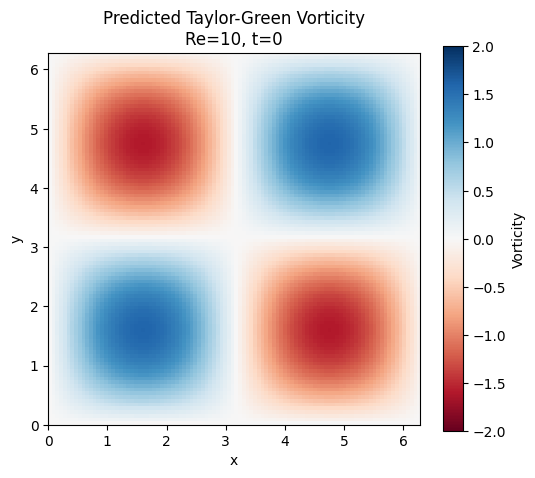

In [11]:
plt.figure(figsize=(6,5))

plt.imshow(
    wm,
    extent=[0, L, 0, B],
    origin="lower",
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="Vorticity")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Predicted Taylor-Green Vorticity\nRe={1/nu:.0f}, t={T}")

plt.show()

Fourier Mode Analysis
Vorticity matrix shape : (100, 100)
Nx                     : 100
Ny                     : 100
dx                     : 6.283185e-02
dy                     : 6.283185e-02


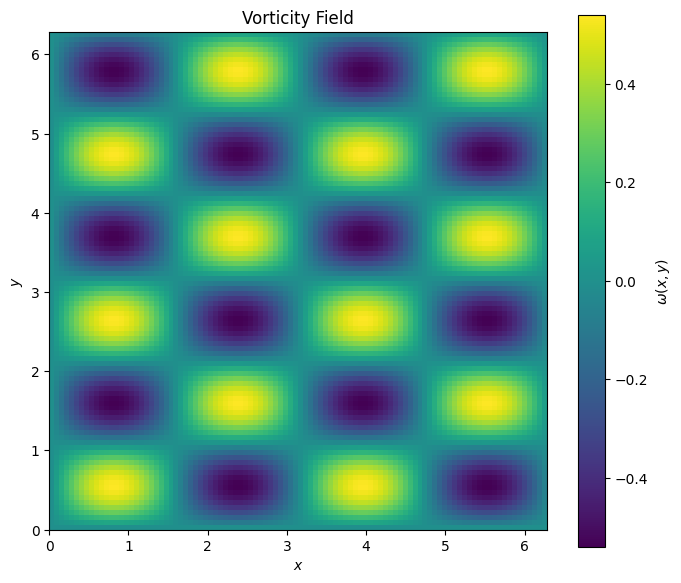

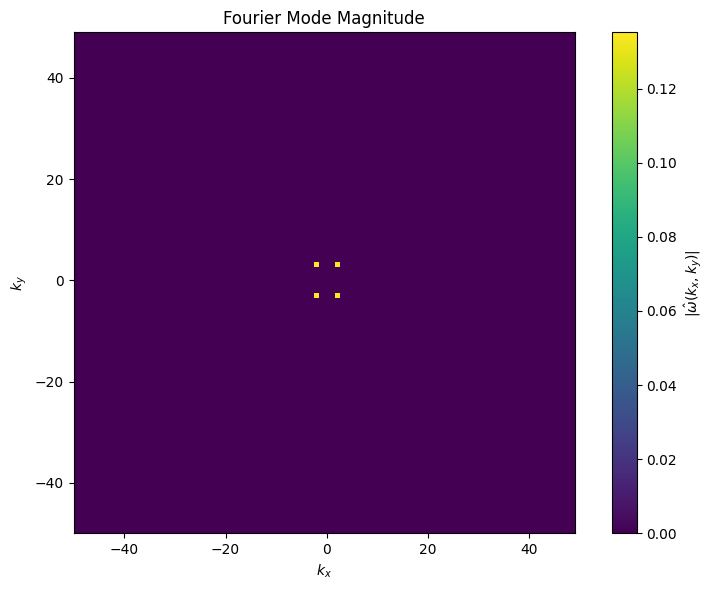

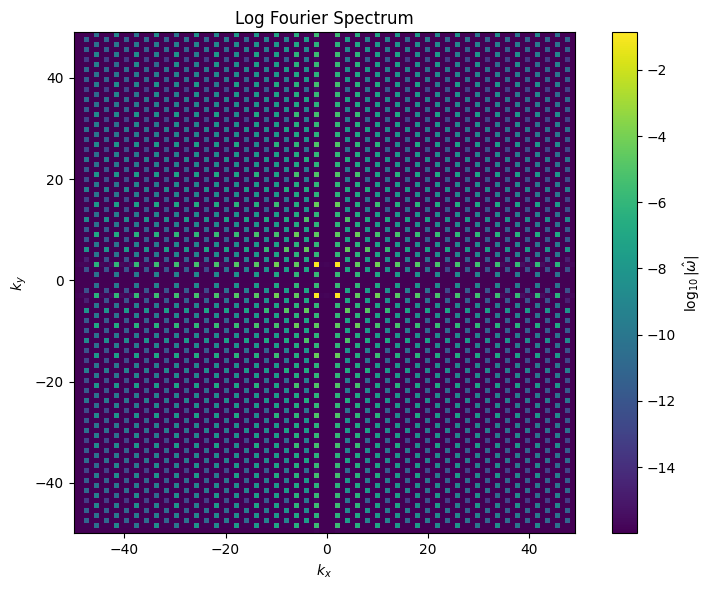

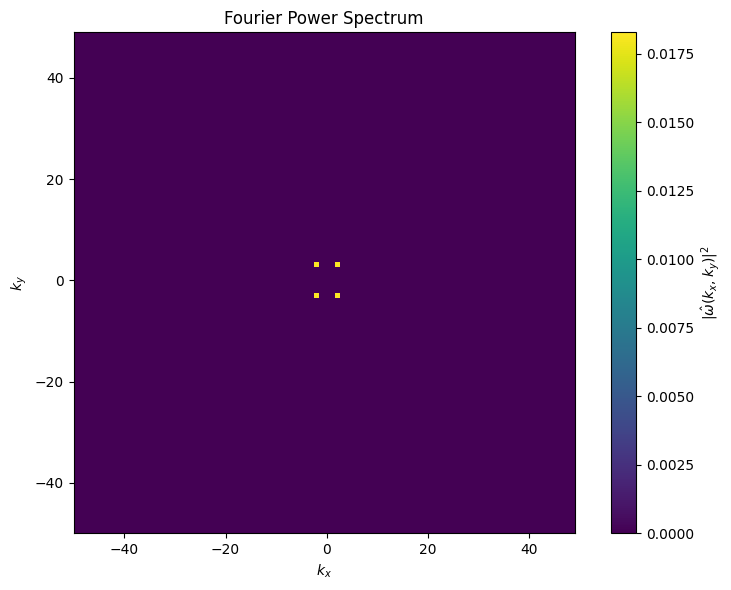

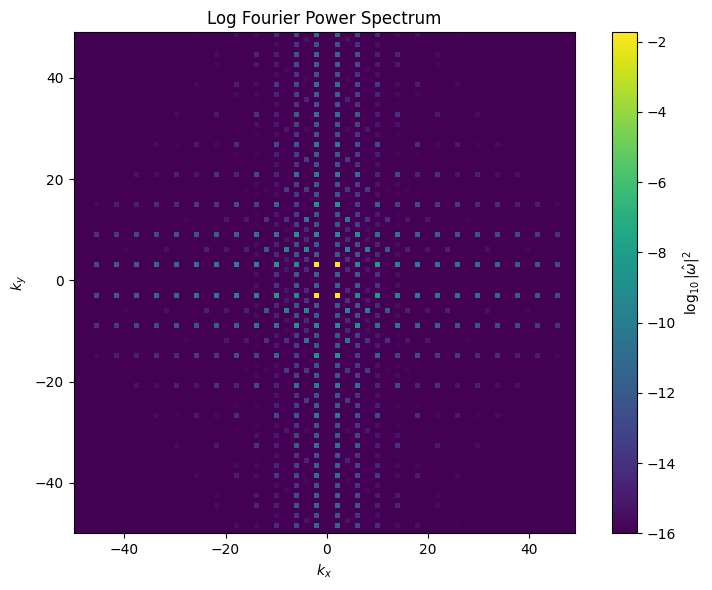

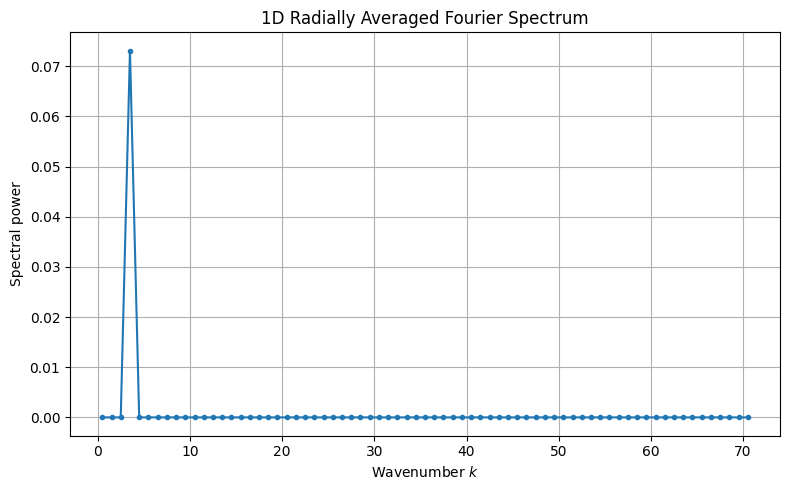

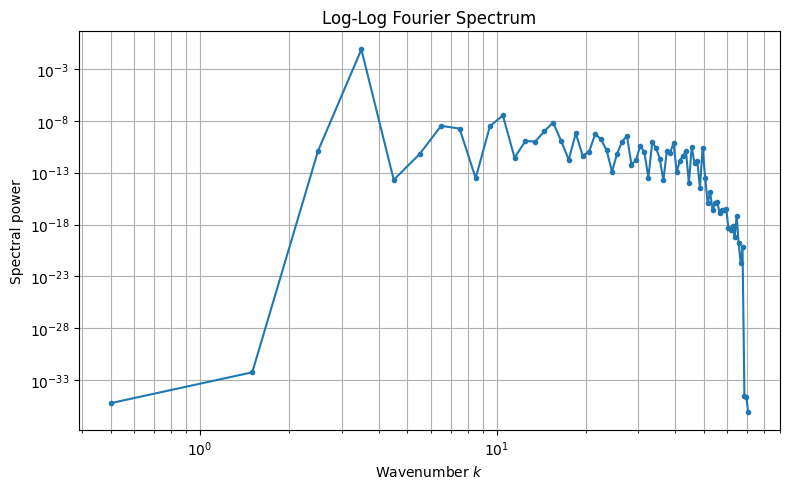



Dominant Fourier Modes
Rank    kx        ky        |omega_hat|       
------------------------------------------------------------
1       3.00      2.00      1.351929e-01      
2       3.00      -2.00     1.351929e-01      
3       -3.00     2.00      1.351929e-01      
4       -3.00     -2.00     1.351929e-01      
5       3.00      10.00     7.442161e-05      
6       -3.00     10.00     7.442161e-05      
7       -3.00     -10.00    7.442161e-05      
8       3.00      -10.00    7.442161e-05      
9       -9.00     -6.00     4.941695e-05      
10      9.00      -6.00     4.941695e-05      
11      -9.00     6.00      4.941695e-05      
12      9.00      6.00      4.941695e-05      
13      -15.00    -2.00     4.085680e-05      
14      15.00     2.00      4.085680e-05      
15      -15.00    2.00      4.085680e-05      


Strongest Fourier Mode
kx                 = 3.0000
ky                 = 2.0000
|omega_hat|        = 1.351929e-01


Spectral Statistics
Total spectral power = 7.

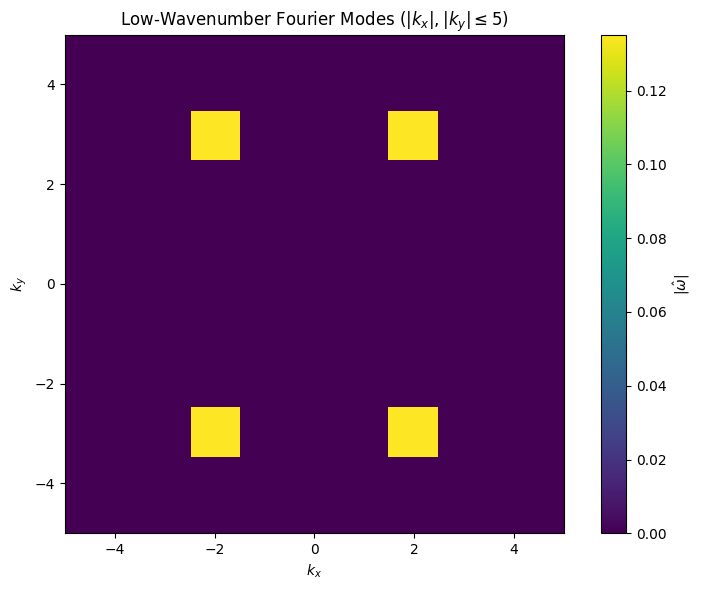



Analysis Complete


In [17]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# FOURIER MODE ANALYSIS OF A 2D VORTICITY FIELD
# ============================================================

# ------------------------------------------------------------
# 1. INPUT YOUR VORTICITY MATRIX HERE
# ------------------------------------------------------------

# Example:
# omega = wm

# Replace this with your actual matrix
omega = wm


# ------------------------------------------------------------
# 2. DOMAIN PARAMETERS
# ------------------------------------------------------------

# Your Taylor-Green domain
L = 2 * np.pi       # domain length in x
B = 2 * np.pi       # domain length in y

Nx, Ny = omega.shape

dx = L / Nx
dy = B / Ny

print("============================================================")
print("Fourier Mode Analysis")
print("============================================================")
print(f"Vorticity matrix shape : {omega.shape}")
print(f"Nx                     : {Nx}")
print(f"Ny                     : {Ny}")
print(f"dx                     : {dx:.6e}")
print(f"dy                     : {dy:.6e}")


# ------------------------------------------------------------
# 3. PHYSICAL-SPACE GRID
# ------------------------------------------------------------

x = np.arange(Nx) * dx
y = np.arange(Ny) * dy

X, Y = np.meshgrid(x, y, indexing="ij")


# ------------------------------------------------------------
# 4. ORIGINAL VORTICITY FIELD
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.imshow(
    omega,
    extent=[0, L, 0, B],
    origin="lower",
    aspect="equal"
)

plt.colorbar(label=r"$\omega(x,y)$")

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Vorticity Field")

plt.tight_layout()
plt.show()


# ============================================================
# FOURIER TRANSFORM
# ============================================================

# ------------------------------------------------------------
# 5. 2D FFT
# ------------------------------------------------------------

omega_hat = np.fft.fft2(omega)

# Shift zero-frequency mode to the center
omega_hat_shifted = np.fft.fftshift(omega_hat)


# ------------------------------------------------------------
# 6. WAVENUMBERS
# ------------------------------------------------------------

kx = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)

kx_shifted = np.fft.fftshift(kx)
ky_shifted = np.fft.fftshift(ky)

KX, KY = np.meshgrid(
    kx_shifted,
    ky_shifted,
    indexing="ij"
)


# ------------------------------------------------------------
# 7. NORMALIZED FOURIER COEFFICIENTS
# ------------------------------------------------------------

# Normalization makes the coefficient magnitude independent
# of the number of grid points.

omega_hat_normalized = omega_hat / (Nx * Ny)

omega_hat_shifted_normalized = np.fft.fftshift(
    omega_hat_normalized
)


# ============================================================
# FOURIER SPECTRUM
# ============================================================

# ------------------------------------------------------------
# 8. FOURIER MODE MAGNITUDE
# ------------------------------------------------------------

fourier_magnitude = np.abs(
    omega_hat_shifted_normalized
)

plt.figure(figsize=(8, 6))

plt.imshow(
    fourier_magnitude,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(label=r"$|\hat{\omega}(k_x,k_y)|$")

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Fourier Mode Magnitude")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. LOG FOURIER SPECTRUM
# ------------------------------------------------------------

# Log scale makes weak modes visible.

log_spectrum = np.log10(
    fourier_magnitude + 1e-16
)

plt.figure(figsize=(8, 6))

plt.imshow(
    log_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$\log_{10}|\hat{\omega}|$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Log Fourier Spectrum")

plt.tight_layout()
plt.show()


# ============================================================
# POWER SPECTRUM
# ============================================================

# ------------------------------------------------------------
# 10. FOURIER POWER
# ------------------------------------------------------------

power_spectrum = fourier_magnitude ** 2

plt.figure(figsize=(8, 6))

plt.imshow(
    power_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$|\hat{\omega}(k_x,k_y)|^2$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Fourier Power Spectrum")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. LOG POWER SPECTRUM
# ------------------------------------------------------------

log_power = np.log10(
    power_spectrum + 1e-16
)

plt.figure(figsize=(8, 6))

plt.imshow(
    log_power,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.colorbar(
    label=r"$\log_{10}|\hat{\omega}|^2$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Log Fourier Power Spectrum")

plt.tight_layout()
plt.show()


# ============================================================
# RADIAL / 1D FOURIER SPECTRUM
# ============================================================

# This converts the 2D spectrum into a spectrum as a function
# of total wavenumber:
#
#       k = sqrt(kx^2 + ky^2)
#
# This is often the most useful spectrum for turbulence analysis.


# ------------------------------------------------------------
# 12. WAVENUMBER MAGNITUDE
# ------------------------------------------------------------

K = np.sqrt(KX**2 + KY**2)


# ------------------------------------------------------------
# 13. CREATE WAVENUMBER BINS
# ------------------------------------------------------------

k_max = int(np.ceil(K.max()))

k_bins = np.arange(
    0,
    k_max + 1
)

k_spectrum = np.zeros(len(k_bins) - 1)


# ------------------------------------------------------------
# 14. BIN FOURIER POWER
# ------------------------------------------------------------

for i in range(len(k_bins) - 1):

    mask = (
        (K >= k_bins[i]) &
        (K < k_bins[i + 1])
    )

    k_spectrum[i] = np.sum(
        power_spectrum[mask]
    )


k_values = 0.5 * (
    k_bins[:-1] +
    k_bins[1:]
)


# ------------------------------------------------------------
# 15. PLOT 1D RADIAL SPECTRUM
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    k_spectrum,
    marker="o",
    markersize=3
)

plt.xlabel(r"Wavenumber $k$")
plt.ylabel(r"Spectral power")
plt.title("1D Radially Averaged Fourier Spectrum")

plt.grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16. LOG-LOG RADIAL SPECTRUM
# ------------------------------------------------------------

# Ignore zero values for log-log plotting.

mask = k_spectrum > 0

plt.figure(figsize=(8, 5))

plt.loglog(
    k_values[mask],
    k_spectrum[mask],
    marker="o",
    markersize=3
)

plt.xlabel(r"Wavenumber $k$")
plt.ylabel(r"Spectral power")

plt.title("Log-Log Fourier Spectrum")

plt.grid(True, which="both")

plt.tight_layout()
plt.show()


# ============================================================
# DOMINANT FOURIER MODES
# ============================================================

# ------------------------------------------------------------
# 17. FIND LARGEST MODES
# ------------------------------------------------------------

magnitude_original = np.abs(
    omega_hat_normalized
)

flat_indices = np.argsort(
    magnitude_original.ravel()
)[::-1]


print("\n")
print("============================================================")
print("Dominant Fourier Modes")
print("============================================================")

print(
    f"{'Rank':<8}"
    f"{'kx':<10}"
    f"{'ky':<10}"
    f"{'|omega_hat|':<18}"
)

print("------------------------------------------------------------")


number_of_modes = 15

for rank, flat_index in enumerate(
    flat_indices[:number_of_modes],
    start=1
):

    i, j = np.unravel_index(
        flat_index,
        magnitude_original.shape
    )

    print(
        f"{rank:<8}"
        f"{kx[i]:<10.2f}"
        f"{ky[j]:<10.2f}"
        f"{magnitude_original[i,j]:<18.6e}"
    )


# ============================================================
# STRONGEST MODE
# ============================================================

# ------------------------------------------------------------
# 18. SINGLE STRONGEST MODE
# ------------------------------------------------------------

max_index = np.unravel_index(
    np.argmax(magnitude_original),
    magnitude_original.shape
)

i_max, j_max = max_index

dominant_kx = kx[i_max]
dominant_ky = ky[j_max]

dominant_value = magnitude_original[
    i_max,
    j_max
]


print("\n")
print("============================================================")
print("Strongest Fourier Mode")
print("============================================================")

print(f"kx                 = {dominant_kx:.4f}")
print(f"ky                 = {dominant_ky:.4f}")

print(
    f"|omega_hat|        = "
    f"{dominant_value:.6e}"
)


# ============================================================
# TOTAL SPECTRAL POWER
# ============================================================

# ------------------------------------------------------------
# 19. TOTAL POWER
# ------------------------------------------------------------

total_power = np.sum(
    power_spectrum
)

print("\n")
print("============================================================")
print("Spectral Statistics")
print("============================================================")

print(
    f"Total spectral power = "
    f"{total_power:.6e}"
)


# ============================================================
# CHECK FOR ZERO MODE
# ============================================================

# The zero mode represents the spatial mean of vorticity.

zero_mode = omega_hat_normalized[0, 0]

mean_vorticity = np.mean(omega)

print(
    f"Mean vorticity       = "
    f"{mean_vorticity:.6e}"
)

print(
    f"Zero Fourier mode    = "
    f"{zero_mode.real:.6e}"
)


# ============================================================
# OPTIONAL: SHOW ONLY LOW WAVENUMBER MODES
# ============================================================

# This is particularly useful for Taylor-Green vortex,
# because the important modes are usually at small k.

k_limit = 5

low_k_mask = (
    (np.abs(KX) <= k_limit) &
    (np.abs(KY) <= k_limit)
)

low_k_spectrum = np.where(
    low_k_mask,
    fourier_magnitude,
    np.nan
)

plt.figure(figsize=(8, 6))

plt.imshow(
    low_k_spectrum,
    extent=[
        kx_shifted.min(),
        kx_shifted.max(),
        ky_shifted.min(),
        ky_shifted.max()
    ],
    origin="lower",
    aspect="equal"
)

plt.xlim(-k_limit, k_limit)
plt.ylim(-k_limit, k_limit)

plt.colorbar(
    label=r"$|\hat{\omega}|$"
)

plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")

plt.title(
    f"Low-Wavenumber Fourier Modes "
    f"($|k_x|,|k_y| \leq {k_limit}$)"
)

plt.tight_layout()
plt.show()


print("\n")
print("============================================================")
print("Analysis Complete")
print("============================================================")

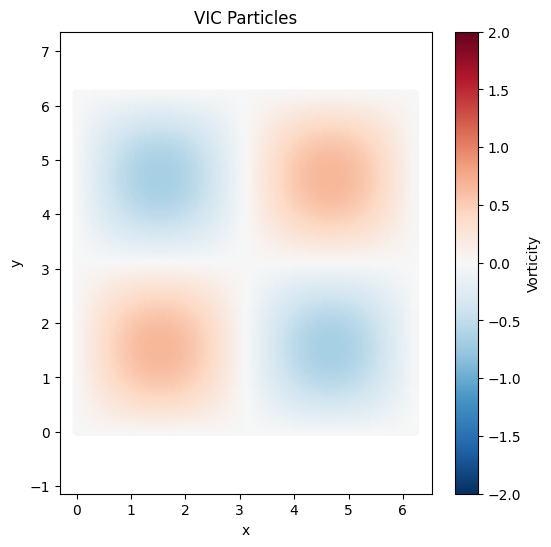

In [ ]:
def plot_vic_particles(particles, h, title="VIC Particles"):

    x = np.array([p["pos"].real for p in particles])
    y = np.array([p["pos"].imag for p in particles])

    # Convert circulation back to vorticity
    w = np.array([p["a"] for p in particles]) / h**2

    #vmax = np.max(np.abs(w))

    plt.figure(figsize=(6,6))

    plt.scatter(
        x,
        y,
        c=w,
        cmap="RdBu_r",
        s=25,
        vmin=-vmax,
        vmax=vmax
    )

    plt.colorbar(label="Vorticity")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.title(title)

    plt.show()

plot_vic_particles(particles, h)

In [13]:
import pickle
import os

if os.path.exists("data.pkl"):
    with open("data.pkl", "rb") as f:
        data = pickle.load(f)
else:
    data = {}

data["predicted"] = wm

with open("data.pkl", "wb") as f:
    pickle.dump(data, f)

data["pred_list"] = W_PRED

with open("data.pkl", "wb") as f:
    pickle.dump(data, f)

data["pred_list_re"] = W_PRED_RE

with open("data.pkl", "wb") as f:
    pickle.dump(data, f)
